In [ ]:
import pandas as pd
df = pd.read_csv("/content/Dataset .csv")
df


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
df ['Cuisines'] = df['Cuisines'].str.split(', ')
df = df.explode('Cuisines')

In [ ]:
cuisine_count= df['Cuisines'].value_counts()
print(cuisine_count.head(3))

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [ ]:
total = len(df)

top3 = cuisine_count.head(3)

percentage = (top3 / total) * 100

print(percentage)

Cuisines
North Indian    20.082154
Chinese         13.869872
Fast Food       10.071505
Name: count, dtype: float64


<Axes: title={'center': 'Top 3 Cuisines'}, xlabel='Cuisines'>

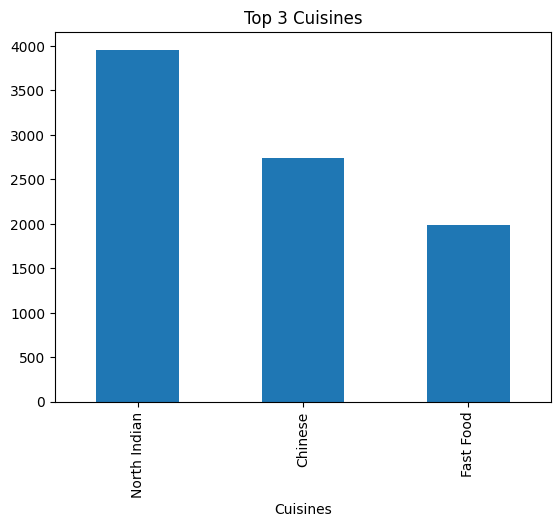

In [ ]:
top3.plot(kind='bar', title='Top 3 Cuisines')

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
City with highest number of restaurants:
City
New Delhi    4048
Name: count, dtype: int64

Average rating per city:
City
Abu Dhabi    4.300000
Agra         3.965000
Ahmedabad    4.161905
Albany       3.555000
Allahabad    3.395000
Name: Aggregate rating, dtype: float64

Top 5 Cities by Average Rating:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64


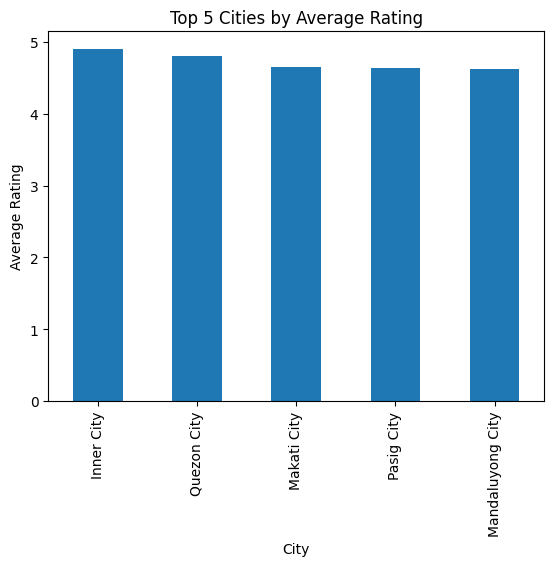

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv("/content/Dataset .csv")

# Step 3: Check column names (important)
print(df.columns)

# Step 4: Remove invalid ratings (0 ratings)
df = df[df['Aggregate rating'] > 0]

# -----------------------------------
# City with highest restaurants
# -----------------------------------
city_count = df['City'].value_counts()

print("City with highest number of restaurants:")
print(city_count.head(1))


# -----------------------------------
# Average rating per city
# -----------------------------------
avg_rating = df.groupby('City')['Aggregate rating'].mean()

print("\nAverage rating per city:")
print(avg_rating.head())


# -----------------------------------
#  Top 5 cities by average rating
# -----------------------------------
top5 = avg_rating.sort_values(ascending=False).head(5)

print("\nTop 5 Cities by Average Rating:")
print(top5)


# -----------------------------------
# 📊 Visualization (Bar Chart)
# -----------------------------------
top5.plot(kind='bar', title='Top 5 Cities by Average Rating')
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.show()

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
Price Range Distribution:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Percentage of each price range:
Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


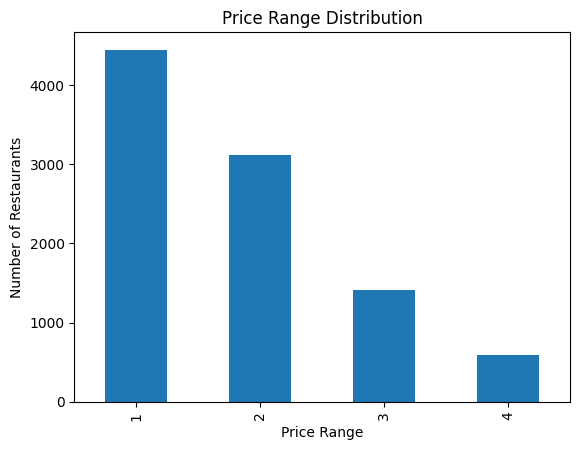

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv("/content/Dataset .csv")

# Step 3: Check columns (optional)
print(df.columns)

# -----------------------------------
# 1️⃣ Count price range distribution
# -----------------------------------
price_count = df['Price range'].value_counts().sort_index()

print("Price Range Distribution:")
print(price_count)


# -----------------------------------
# 2️⃣ Calculate percentage
# -----------------------------------
percentage = (price_count / price_count.sum()) * 100

print("\nPercentage of each price range:")
print(percentage)


# -----------------------------------
# 📊 3️⃣ Visualization (Bar Chart)
# -----------------------------------
price_count.plot(kind='bar', title='Price Range Distribution')
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
Rating Distribution:
Aggregate rating
1.8      1
1.9      2
2.0      7
2.1     15
2.2     27
2.3     47
2.4     87
2.5    110
2.6    191
2.7    250
2.8    315
2.9    381
3.0    468
3.1    519
3.2    522
3.3    483
3.4    498
3.5    480
3.6    458
3.7    427
3.8    400
3.9    335
4.0    266
4.1    274
4.2    221
4.3    174
4.4    144
4.5     95
4.6     78
4.7     42
4.8     25
4.9     61
Name: count, dtype: int64

Most Common Rating:
0    3.2
Name: Aggregate rating, dtype: float64

Average Votes:
202.1850601107659


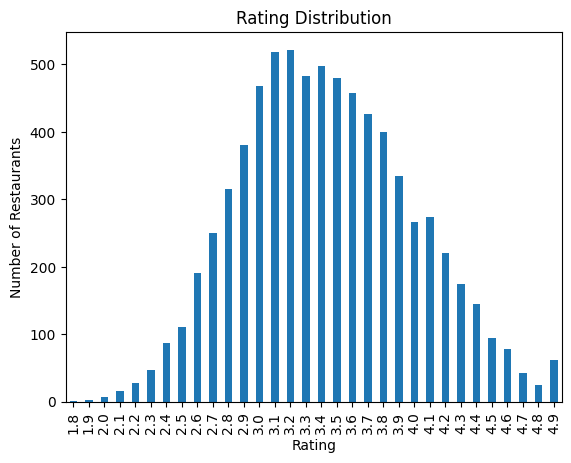

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv("/content/Dataset .csv")

# Step 3: Check columns (optional)
print(df.columns)

# Step 4: Clean data (remove 0 ratings)
df = df[df['Aggregate rating'] > 0]

# -----------------------------------
# 1️⃣ Rating distribution
# -----------------------------------
rating_dist = df['Aggregate rating'].value_counts().sort_index()

print("Rating Distribution:")
print(rating_dist)


# -----------------------------------
# 2️⃣ Most common rating
# -----------------------------------
most_common = df['Aggregate rating'].mode()

print("\nMost Common Rating:")
print(most_common)


# -----------------------------------
# 3️⃣ Average number of votes
# -----------------------------------
avg_votes = df['Votes'].mean()

print("\nAverage Votes:")
print(avg_votes)


# -----------------------------------
# 📊 Visualization (Bar Chart)
# -----------------------------------
rating_dist.plot(kind='bar', title='Rating Distribution')
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

Top 5 Most Common Cuisine Combinations:
Cuisines
North Indian             492
North Indian, Chinese    397
North Indian, Mughlai    294
Cafe                     252
Fast Food                228
Name: count, dtype: int64

Top 5 Highest Rated Cuisine Combinations:
Cuisines
European, German                   4.9
Continental, Indian                4.9
American, Coffee and Tea           4.9
American, BBQ, Sandwich            4.9
Mexican, American, Healthy Food    4.9
Name: Aggregate rating, dtype: float64


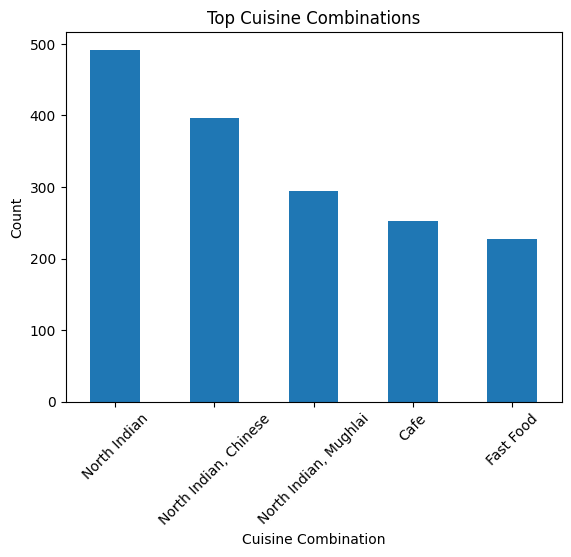

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv("/content/Dataset .csv")

# Step 3: Clean data
df = df.dropna(subset=['Cuisines'])
df = df[df['Aggregate rating'] > 0]

# -----------------------------------
# 1️⃣ Most common cuisine combinations
# -----------------------------------
combo_count = df['Cuisines'].value_counts()

print("Top 5 Most Common Cuisine Combinations:")
print(combo_count.head(5))


# -----------------------------------
# 2️⃣ Highest rated cuisine combinations
# -----------------------------------
combo_rating = df.groupby('Cuisines')['Aggregate rating'].mean()

top_rated = combo_rating.sort_values(ascending=False).head(5)

print("\nTop 5 Highest Rated Cuisine Combinations:")
print(top_rated)


# -----------------------------------
# 📊 Visualization
# -----------------------------------
combo_count.head(5).plot(kind='bar', title='Top Cuisine Combinations')
plt.xlabel("Cuisine Combination")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 1: Import libraries
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# Step 2: Load dataset
df = pd.read_csv("/content/Dataset .csv")

# Step 3: Drop missing values
df = df.dropna(subset=['Latitude', 'Longitude'])

# Step 4: Create base map (center)
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# Step 5: Add cluster
cluster = MarkerCluster().add_to(m)

# Step 6: Add markers
for i in range(len(df.sample(1000))):   # sample for speed
    row = df.sample(1000).iloc[i]
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Restaurant Name']
    ).add_to(cluster)

# Step 7: Show map
m

Top Restaurant Chains:
Restaurant Name
Domino's Pizza      74
Cafe Coffee Day     67
Subway              61
McDonald's          47
Green Chick Chop    44
Keventers           29
Pizza Hut           29
Barbeque Nation     26
Giani               24
Barista             21
Name: count, dtype: int64

Top Rated Chains:
Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Name: Aggregate rating, dtype: float64

Most Popular Chains (by Votes):
Restaurant Name
Truffles                     4841.000000
Joey's Pizza                 3903.500000
AB's - Absolute Barbecues    3350.000000
Big Chill                    2713.250000
Big Yellow Door              2503.666667
Name: Votes, dtype: float64


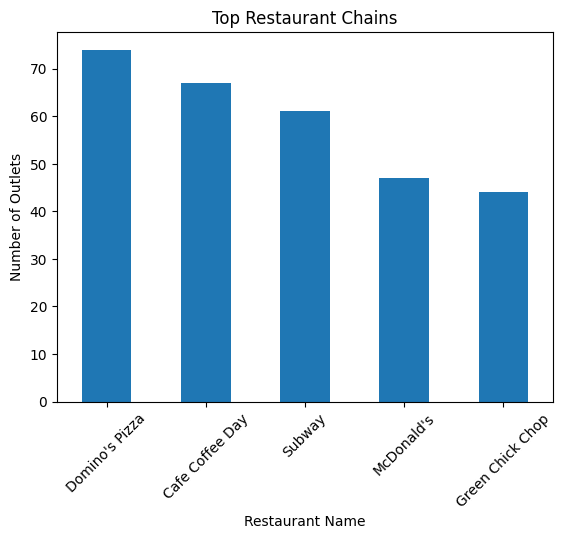

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv("/content/Dataset .csv")

# Step 3: Clean data
df = df[df['Aggregate rating'] > 0]

# -----------------------------------
# 1️⃣ Identify restaurant chains
# -----------------------------------
chain_count = df['Restaurant Name'].value_counts()

chains = chain_count[chain_count > 1]

print("Top Restaurant Chains:")
print(chains.head(10))


# -----------------------------------
# 2️⃣ Filter only chain restaurants
# -----------------------------------
chain_data = df[df['Restaurant Name'].isin(chains.index)]


# -----------------------------------
# 3️⃣ Average rating of chains
# -----------------------------------
chain_rating = chain_data.groupby('Restaurant Name')['Aggregate rating'].mean()

print("\nTop Rated Chains:")
print(chain_rating.sort_values(ascending=False).head(5))


# -----------------------------------
# 4️⃣ Popularity (Votes)
# -----------------------------------
chain_votes = chain_data.groupby('Restaurant Name')['Votes'].mean()

print("\nMost Popular Chains (by Votes):")
print(chain_votes.sort_values(ascending=False).head(5))


# -----------------------------------
# 📊 Visualization
# -----------------------------------
chains.head(5).plot(kind='bar', title='Top Restaurant Chains')
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Outlets")
plt.xticks(rotation=45)
plt.show()